<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Decision_Tree_FinalModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [121]:
# General Libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Models, Metrics, Preprocessing, and Model Selection
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Data Preprocessing

In [132]:
# Load CSV
file_path = '/content/drive/MyDrive/Customer_Churn_Data.csv'
data = pd.read_csv(file_path)

# Make a copy of the original dataset to work with
data_copy = data.copy()
df_dt = data_copy

# Check dataset
df_dt.head()
df_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Datatype Conversion

In [133]:
# Convert TotalCharges to numeric
df_dt['TotalCharges_numeric'] = pd.to_numeric(df_dt['TotalCharges'], errors='coerce')

# Check how many missing values after conversion
print("Missing values in TotalCharges_numeric:", df_dt['TotalCharges_numeric'].isnull().sum())

# Impute missing values with median (robust for skewed data)
median_total = df_dt['TotalCharges_numeric'].median()
df_dt['TotalCharges_numeric'].fillna(median_total, inplace=True)

# Drop the original TotalCharges column
df_dt.drop(columns=['TotalCharges'], inplace=True)

Missing values in TotalCharges_numeric: 11


/tmp/ipython-input-372253789.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_dt['TotalCharges_numeric'].fillna(median_total, inplace=True)


## Drop Irrelevant Columns

In [134]:
# Drop customerID as it is not a predictive feature
df_dt.drop(columns=['customerID'], inplace=True)

## Feature Engineering

In [135]:
# Feature Engineering
df_dt['AvgChargePerMonth'] = df_dt['TotalCharges_numeric'] / (df_dt['tenure'] + 1)

## Encode categorical features

In [136]:
# Identify categorical columns (excluding target)
categorical_columns = df_dt.select_dtypes(include='object').columns.tolist()

# Remove Churn so it is encoded separately
if 'Churn' in categorical_columns:
    categorical_columns.remove('Churn')

# Label encode ALL categorical columns permanently
le = LabelEncoder()
for col in categorical_columns:
    # Encode and convert to int64
    df_dt[col] = le.fit_transform(df_dt[col].astype(str)).astype(int)

# Encode Churn separately
if df_dt['Churn'].dtype == 'object':
    df_dt['Churn'] = df_dt['Churn'].str.strip().map({'No': 0, 'Yes': 1})

# Make copy separately
df_dt_1 = df_dt.copy()
df_dt_2 = df_dt.copy()

## Specify X and Y and split data

In [137]:
# Separate features and target
X = df_dt_1.drop(columns=['Churn'])
y = df_dt_1['Churn']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (5634, 20)
X_test shape: (1409, 20)
y_train distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
y_test distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## Apply SMOTE

In [138]:
# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check shapes
print("X_train shape:", X_train_res.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))

X_train shape: (8278, 20)
y_train distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


# Model Implementation and Training with all features included and with overfitting and underfitting check

## Hyperparameter Tuning with GridSearchCV

In [139]:
# Parameter grid
param_grid = {
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [20, 50, 100],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01],
    'criterion': ['gini', 'entropy']
}
# GridSearchCV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=skf,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_res, y_train_res)
print("Best params:", grid_search.best_params_)
print("Best F1:", grid_search.best_score_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best params: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 10}
Best F1: 0.8130646204587647


## Implement and Train Model

In [140]:
# Define the model
dt_model_all = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=20,
    ccp_alpha=0.005,
    criterion='entropy'
)

# Fit the model
dt_model_all.fit(X_train_res, y_train_res)

# Threshold Tuning
best_f1 = 0
best_threshold = 0.5
threshold_start = 0.1
threshold_stop = 0.7
threshold_step = 0.01

dt_test_prob = dt_model_all.predict_proba(X_test)[:,1]

for threshold in np.arange(threshold_start, threshold_stop, threshold_step):
    dt_test_pred = (dt_test_prob >= threshold).astype(int)
    f1 = f1_score(y_test, dt_test_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best Threshold for max F1: {best_threshold:.2f}, F1-score: {best_f1:.4f}")

# Predictions for train set
dt_train_prob = dt_model_all.predict_proba(X_train_res)[:,1]
dt_train_pred = (dt_train_prob >= best_threshold).astype(int)

# Metrics
dt_train_auc = roc_auc_score(y_train_res, dt_train_prob)
dt_test_auc = roc_auc_score(y_test, dt_test_prob)
dt_train_acc = accuracy_score(y_train_res, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)

# Overfitting / Underfitting Check
if dt_train_auc - dt_test_auc > 0.1 or dt_train_acc - dt_test_acc > 0.1:
    print("Warning: Potential Overfitting Detected (Significant Gap between Train and Test metrics)")
elif dt_train_auc < 0.65 and dt_test_auc < 0.65:
    print("Warning: Potential Underfitting Detected (Low Train and Test metrics)")
else:
    print("No major overfitting or underfitting detected")

Best Threshold for max F1: 0.52, F1-score: 0.6117
No major overfitting or underfitting detected


# Evaluate model

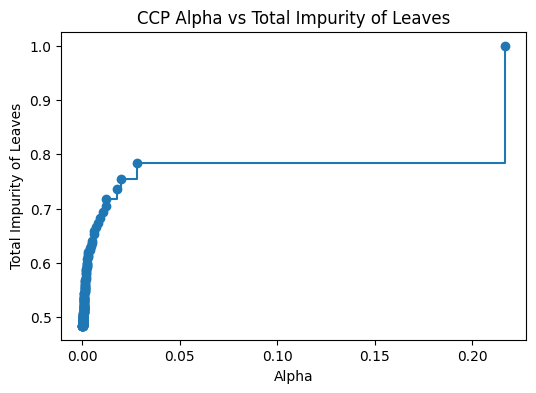

/tmp/ipython-input-2417423053.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


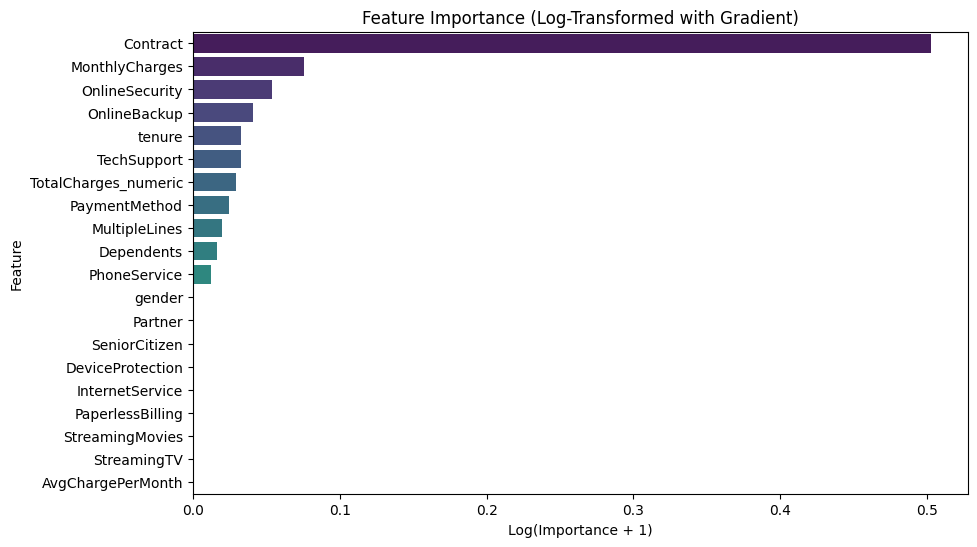

F1-scores for each fold: [0.81437126 0.81647059 0.81065431 0.80650784 0.8173191 ]
Mean F1-score (CV): 0.8130646204587647

--- Train Evaluation ---

Accuracy: 0.7900
Recall: 0.7821
Precision: 0.7947
F1-score: 0.7884
ROC Score (Discrete Prediction): 0.7900
AUC Score (Probability): 0.8668

Classification Report:
              precision    recall  f1-score   support

           0     0.7855    0.7980    0.7917      4139
           1     0.7947    0.7821    0.7884      4139

    accuracy                         0.7900      8278
   macro avg     0.7901    0.7900    0.7900      8278
weighted avg     0.7901    0.7900    0.7900      8278

Confusion Matrix:
[[3303  836]
 [ 902 3237]]


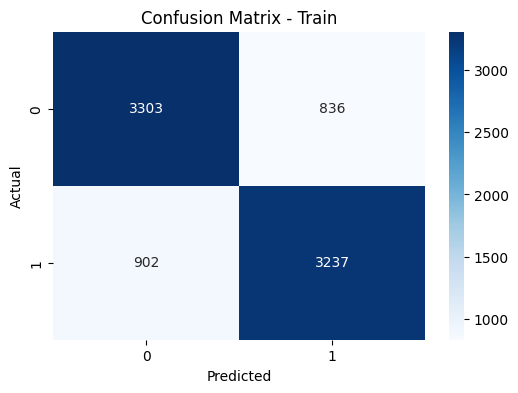

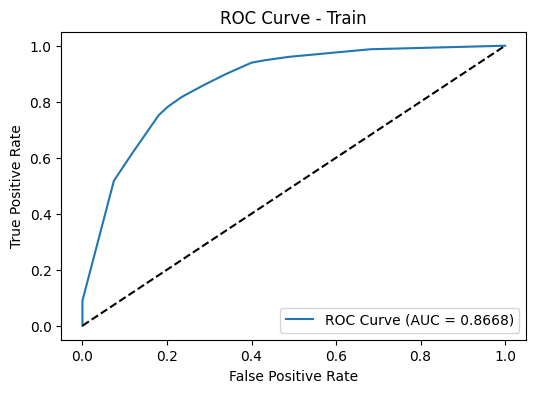

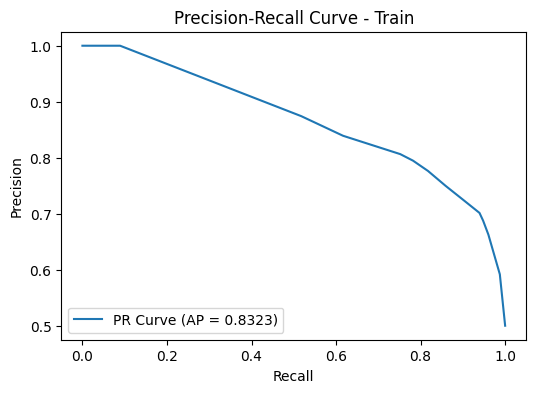


--- Test Evaluation ---

Accuracy: 0.7693
Recall: 0.6845
Precision: 0.5529
F1-score: 0.6117
ROC Score (Discrete Prediction): 0.7422
AUC Score (Probability): 0.8108

Classification Report:
              precision    recall  f1-score   support

           0     0.8753    0.8000    0.8359      1035
           1     0.5529    0.6845    0.6117       374

    accuracy                         0.7693      1409
   macro avg     0.7141    0.7422    0.7238      1409
weighted avg     0.7897    0.7693    0.7764      1409

Confusion Matrix:
[[828 207]
 [118 256]]


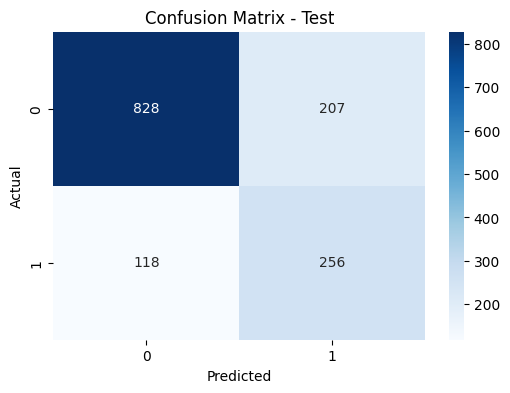

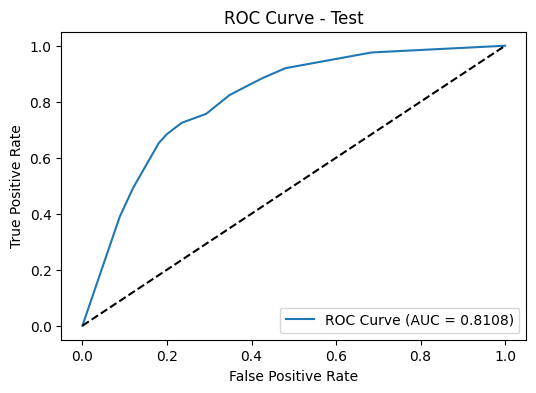

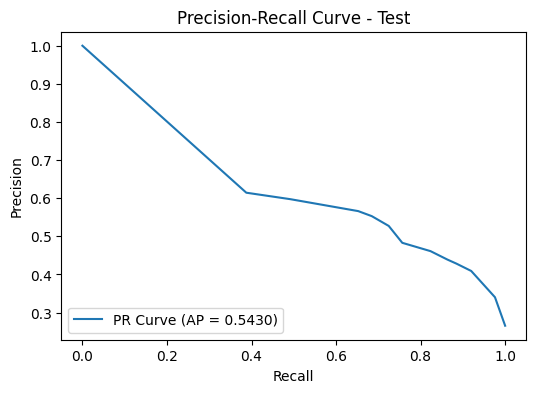

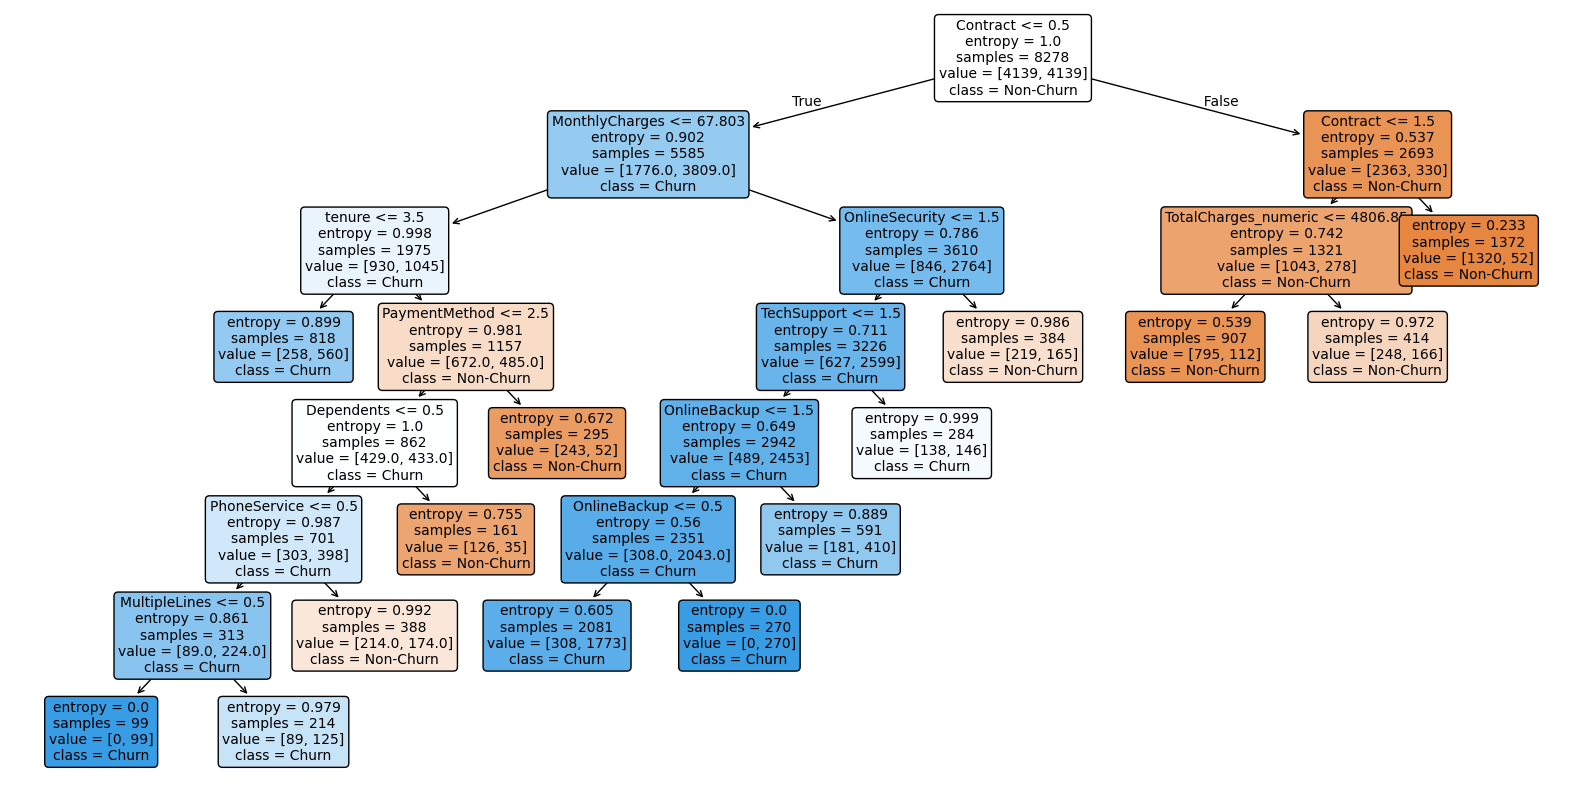

In [141]:
# Visualizing CCP Alpha vs Impurity
path = dt_model_all.cost_complexity_pruning_path(X_train_res, y_train_res)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

plt.figure(figsize=(6,4))
plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
plt.xlabel("Alpha")
plt.ylabel("Total Impurity of Leaves")
plt.title("CCP Alpha vs Total Impurity of Leaves")
plt.show()

# Feature Importance Plot with Gradient and Log Transformation
feature_importance = pd.DataFrame({
    'Feature': X_train_res.columns,
    'Importance': dt_model_all.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Apply log transformation
feature_importance['LogImportance'] = np.log1p(feature_importance['Importance'])

plt.figure(figsize=(10,6))
sns.barplot(
    x='LogImportance',
    y='Feature',
    data=feature_importance,
    palette="viridis"
)
plt.xlabel("Log(Importance + 1)")
plt.title("Feature Importance (Log-Transformed with Gradient)")
plt.show()

from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer

# F1 scorer
f1_scorer = make_scorer(f1_score)

# 5-fold stratified CV
f1_scores = cross_val_score(
    grid_search.best_estimator_,
    X_train_res,
    y_train_res,
    cv=skf,
    scoring=f1_scorer
)

print("F1-scores for each fold:", f1_scores)
print("Mean F1-score (CV):", f1_scores.mean())

# Function to Evaluate a Dataset
def evaluate_decision_tree(model, X, y, dataset_name="Test"):
    print(f"\n--- {dataset_name} Evaluation ---\n")

    # Predictions
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)

    # Metrics
    acc = accuracy_score(y, y_pred)
    rec = recall_score(y, y_pred)
    prec = precision_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_score = roc_auc_score(y, y_pred)
    auc_score = roc_auc_score(y, y_prob)

    print(f"Accuracy: {acc:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC Score (Discrete Prediction): {roc_score:.4f}")
    print(f"AUC Score (Probability): {auc_score:.4f}\n")

    # Classification Report
    print("Classification Report:")
    print(classification_report(y, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {dataset_name}")
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall Curve
    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_prob)
    ap_score = average_precision_score(y, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(recall_vals, precision_vals, label=f'PR Curve (AP = {ap_score:.4f})')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {dataset_name}")
    plt.legend(loc='lower left')
    plt.show()

    return acc, rec, prec, f1, roc_score, auc_score

# Evaluate on Train and Test
train_metrics = evaluate_decision_tree(dt_model_all, X_train_res, y_train_res, "Train")
test_metrics = evaluate_decision_tree(dt_model_all, X_test, y_test, "Test")

# Display the Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(
    dt_model_all,
    feature_names=X_train_res.columns,
    class_names=["Non-Churn","Churn"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

# After Feature Reduction

In [142]:
# List of zero-importance features
zero_importance_features = [
    'gender', 'Partner', 'SeniorCitizen', 'DeviceProtection',
    'InternetService', 'PaperlessBilling', 'StreamingMovies',
    'StreamingTV', 'AvgChargePerMonth'
]
# Separate features and target
X = df_dt_2.drop(columns=['Churn']+zero_importance_features)
y = df_dt_2['Churn']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (5634, 11)
X_test shape: (1409, 11)
y_train distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
y_test distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [143]:
# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check shapes
print("X_train shape:", X_train_res.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))

X_train shape: (8278, 11)
y_train distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [144]:
# Parameter grid
param_grid = {
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [20, 50, 100],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01],
    'criterion': ['gini', 'entropy']
}
# GridSearchCV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=skf,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_res, y_train_res)
print("Best params:", grid_search.best_params_)
print("Best F1:", grid_search.best_score_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best params: {'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 10}
Best F1: 0.8148681661814727


# Implement and Train model after feature reduction

In [145]:
# Define the model
dt_model_refined = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=20,
    ccp_alpha=0.005,
    criterion='entropy'
)

# Fit the model
dt_model_refined.fit(X_train_res, y_train_res)

# Threshold Tuning
best_f1 = 0
best_threshold = 0.5
threshold_start = 0.1
threshold_stop = 0.7
threshold_step = 0.01

dt_test_prob = dt_model_refined.predict_proba(X_test)[:,1]

for threshold in np.arange(threshold_start, threshold_stop, threshold_step):
    dt_test_pred = (dt_test_prob >= threshold).astype(int)
    f1 = f1_score(y_test, dt_test_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best Threshold for max F1: {best_threshold:.2f}, F1-score: {best_f1:.4f}")

# Predictions for train set
dt_train_prob = dt_model_refined.predict_proba(X_train_res)[:,1]
dt_train_pred = (dt_train_prob >= best_threshold).astype(int)

# Metrics
dt_train_auc = roc_auc_score(y_train_res, dt_train_prob)
dt_test_auc = roc_auc_score(y_test, dt_test_prob)
dt_train_acc = accuracy_score(y_train_res, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)

# Overfitting / Underfitting Check
if dt_train_auc - dt_test_auc > 0.1 or dt_train_acc - dt_test_acc > 0.1:
    print("Warning: Potential Overfitting Detected (Significant Gap between Train and Test metrics)")
elif dt_train_auc < 0.65 and dt_test_auc < 0.65:
    print("Warning: Potential Underfitting Detected (Low Train and Test metrics)")
else:
    print("No major overfitting or underfitting detected")

Best Threshold for max F1: 0.43, F1-score: 0.6077
No major overfitting or underfitting detected


# Evaluate model after feature reduction

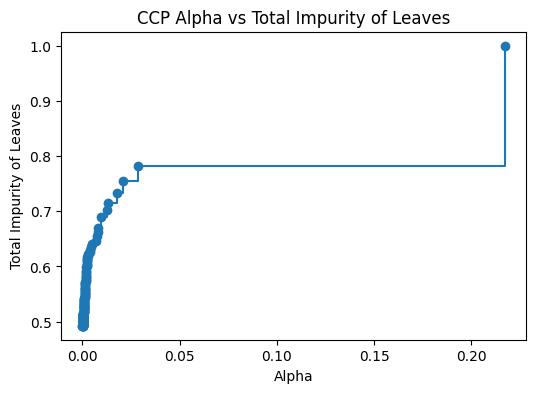

/tmp/ipython-input-1366893874.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


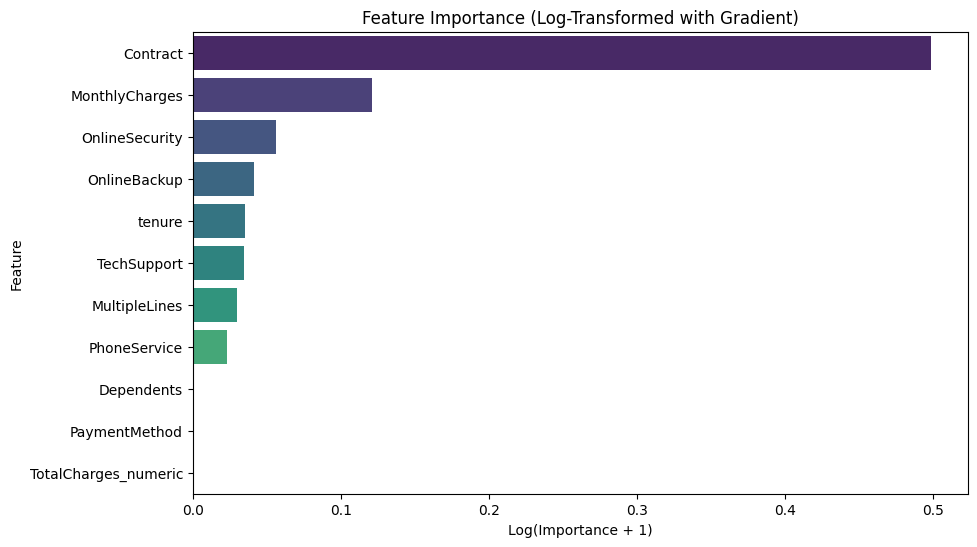

F1-scores for each fold: [0.81045752 0.81864696 0.81332567 0.81103286 0.82087782]
Mean F1-score (CV): 0.8148681661814727

--- Train Evaluation ---

Accuracy: 0.7876
Recall: 0.8265
Precision: 0.7669
F1-score: 0.7956
ROC Score (Discrete Prediction): 0.7876
AUC Score (Probability): 0.8668

Classification Report:
              precision    recall  f1-score   support

           0     0.8119    0.7487    0.7790      4139
           1     0.7669    0.8265    0.7956      4139

    accuracy                         0.7876      8278
   macro avg     0.7894    0.7876    0.7873      8278
weighted avg     0.7894    0.7876    0.7873      8278

Confusion Matrix:
[[3099 1040]
 [ 718 3421]]


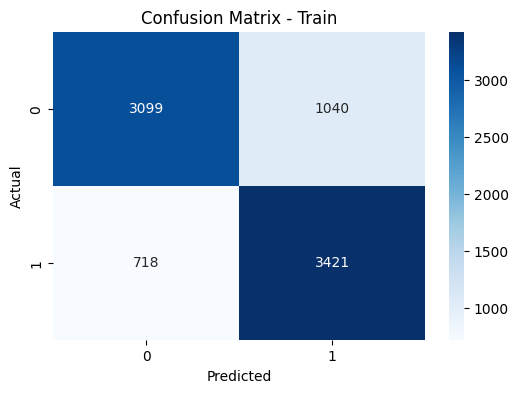

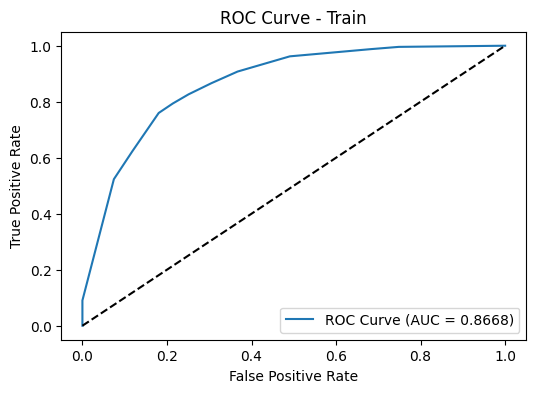

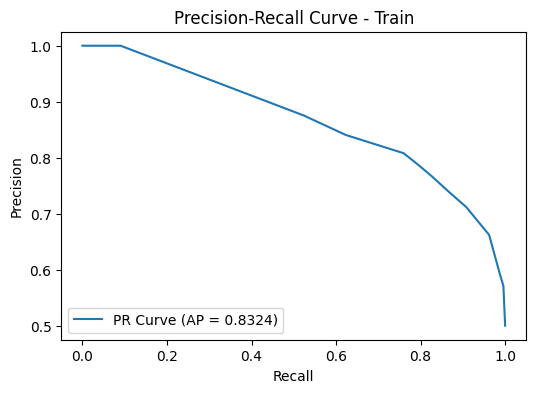


--- Test Evaluation ---

Accuracy: 0.7480
Recall: 0.7353
Precision: 0.5179
F1-score: 0.6077
ROC Score (Discrete Prediction): 0.7440
AUC Score (Probability): 0.8167

Classification Report:
              precision    recall  f1-score   support

           0     0.8872    0.7527    0.8144      1035
           1     0.5179    0.7353    0.6077       374

    accuracy                         0.7480      1409
   macro avg     0.7026    0.7440    0.7111      1409
weighted avg     0.7892    0.7480    0.7596      1409

Confusion Matrix:
[[779 256]
 [ 99 275]]


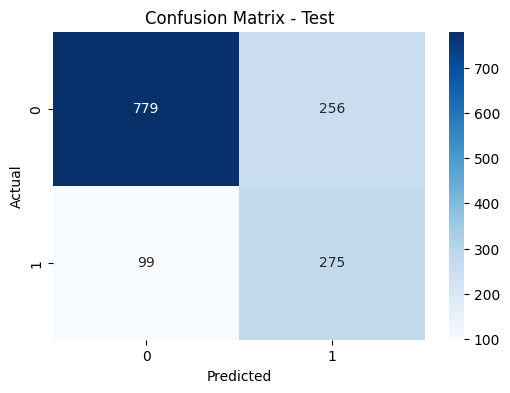

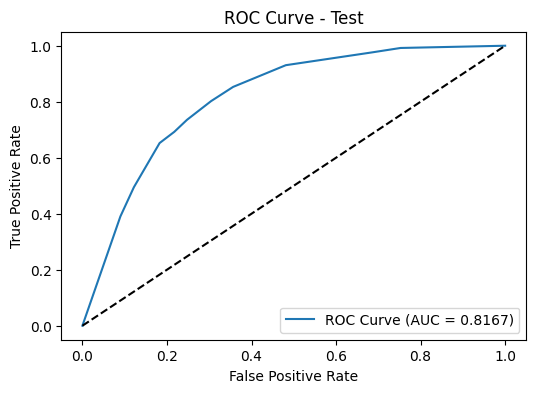

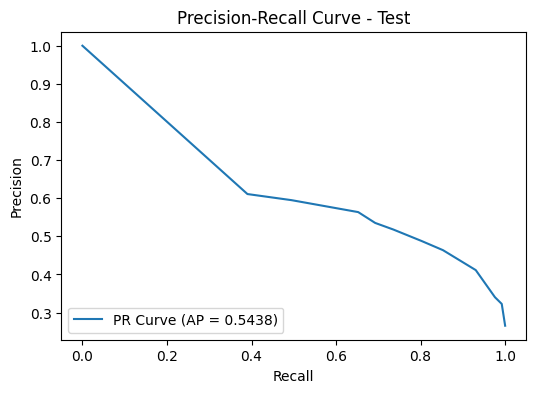

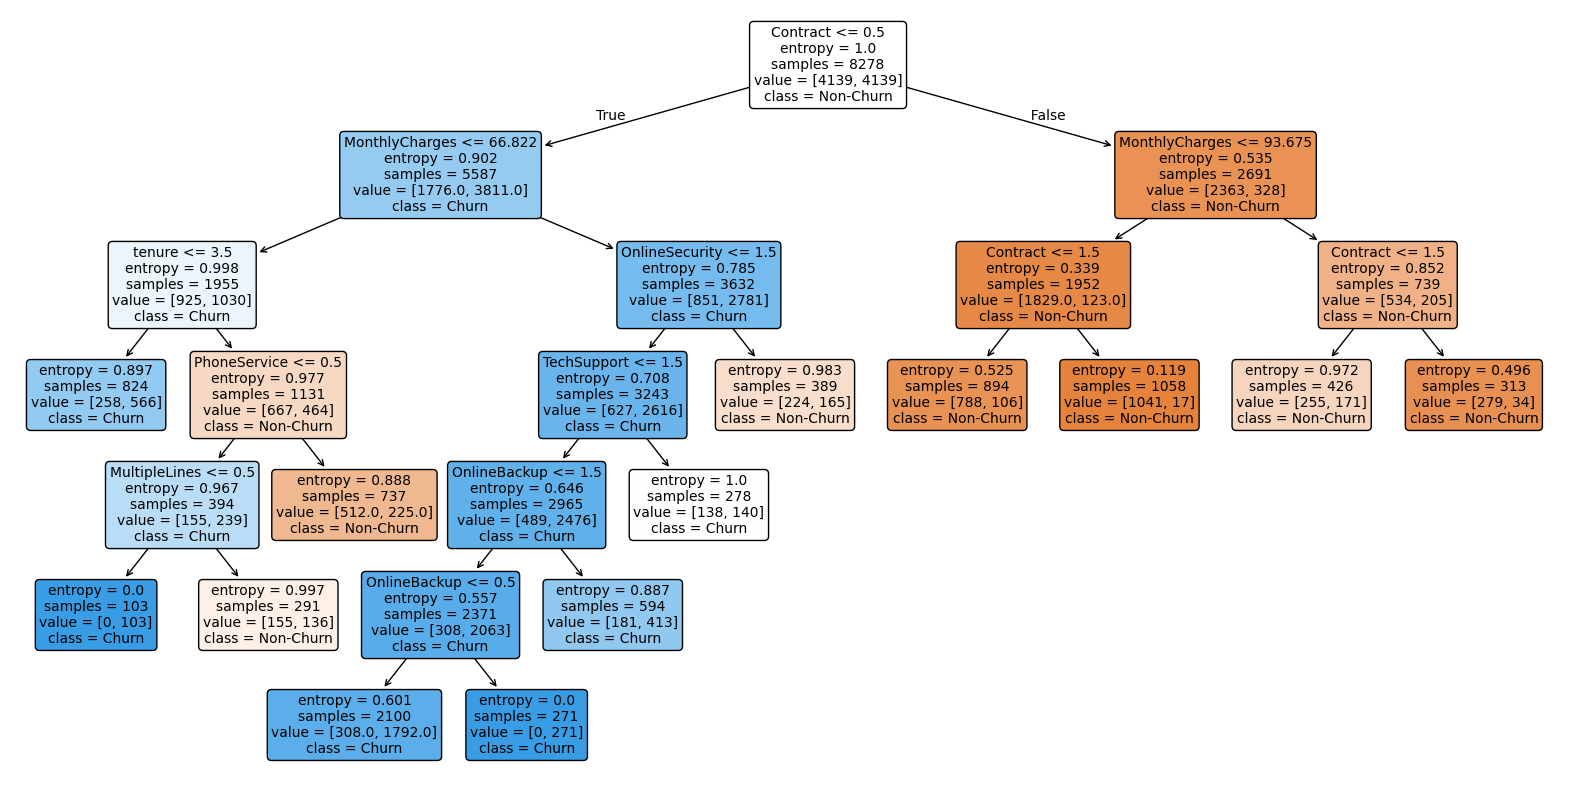

In [146]:
# Visualizing CCP Alpha vs Impurity
path = dt_model_refined.cost_complexity_pruning_path(X_train_res, y_train_res)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

plt.figure(figsize=(6,4))
plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
plt.xlabel("Alpha")
plt.ylabel("Total Impurity of Leaves")
plt.title("CCP Alpha vs Total Impurity of Leaves")
plt.show()

# Feature Importance Plot with Gradient and Log Transformation
feature_importance = pd.DataFrame({
    'Feature': X_train_res.columns,
    'Importance': dt_model_refined.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Apply log transformation
feature_importance['LogImportance'] = np.log1p(feature_importance['Importance'])

plt.figure(figsize=(10,6))
sns.barplot(
    x='LogImportance',
    y='Feature',
    data=feature_importance,
    palette="viridis"
)
plt.xlabel("Log(Importance + 1)")
plt.title("Feature Importance (Log-Transformed with Gradient)")
plt.show()

from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer

# F1 scorer
f1_scorer = make_scorer(f1_score)

# 5-fold stratified CV
f1_scores = cross_val_score(
    grid_search.best_estimator_,
    X_train_res,
    y_train_res,
    cv=skf,
    scoring=f1_scorer
)

print("F1-scores for each fold:", f1_scores)
print("Mean F1-score (CV):", f1_scores.mean())

# Function to Evaluate a Dataset
def evaluate_decision_tree(model, X, y, dataset_name="Test"):
    print(f"\n--- {dataset_name} Evaluation ---\n")

    # Predictions
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)

    # Metrics
    acc = accuracy_score(y, y_pred)
    rec = recall_score(y, y_pred)
    prec = precision_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_score = roc_auc_score(y, y_pred)
    auc_score = roc_auc_score(y, y_prob)

    print(f"Accuracy: {acc:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC Score (Discrete Prediction): {roc_score:.4f}")
    print(f"AUC Score (Probability): {auc_score:.4f}\n")

    # Classification Report
    print("Classification Report:")
    print(classification_report(y, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {dataset_name}")
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall Curve
    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_prob)
    ap_score = average_precision_score(y, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(recall_vals, precision_vals, label=f'PR Curve (AP = {ap_score:.4f})')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {dataset_name}")
    plt.legend(loc='lower left')
    plt.show()

    return acc, rec, prec, f1, roc_score, auc_score

# Evaluate on Train and Test
train_metrics = evaluate_decision_tree(dt_model_refined, X_train_res, y_train_res, "Train")
test_metrics = evaluate_decision_tree(dt_model_refined, X_test, y_test, "Test")

# Display the Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(
    dt_model_refined,
    feature_names=X_train_res.columns,
    class_names=["Non-Churn","Churn"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

# SUMMARY

### Cross-Validation (5-fold)
| Metric | All features | After feature reduction |
|--------|---------|---------|
| F1-scores (per fold) | [0.8144, 0.8165, 0.8107, 0.8065, 0.8173] | [0.8105, 0.8186, 0.8133, 0.8110, 0.8209] |
| Mean F1-score (CV) | 0.8131 | 0.8149 |

### Train Evaluation
| Metric | All features | After feature reduction |
|--------|---------|---------|
| Accuracy | 0.7900 | 0.7876 |
| Recall (overall) | 0.7821 | 0.8265 |
| Precision (overall) | 0.7947 | 0.7669 |
| F1-score (overall) | 0.7884 | 0.7956 |
| ROC Score (Discrete) | 0.7900 | 0.7876 |
| AUC Score (Probability) | 0.8668 | 0.8668 |
| **Non-Churn (0)** | Precision: 0.7855 <br> Recall: 0.7980 <br> F1: 0.7917 | Precision: 0.8119 <br> Recall: 0.7487 <br> F1: 0.7790 |
| **Churn (1)** | Precision: 0.7947 <br> Recall: 0.7821 <br> F1: 0.7884 | Precision: 0.7669 <br> Recall: 0.8265 <br> F1: 0.7956 |
| Confusion Matrix | [[3303, 836], [902, 3237]] | [[3099, 1040], [718, 3421]] |


### Test Evaluation
| Metric | All features | After feature reduction |
|--------|---------|---------|
| Accuracy | 0.7693 | 0.7480 |
| Recall (overall) | 0.6845 | 0.7353 |
| Precision (overall) | 0.5529 | 0.5179 |
| F1-score (overall) | 0.6117 | 0.6077 |
| ROC Score (Discrete) | 0.7422 | 0.7440 |
| AUC Score (Probability) | 0.8108 | 0.8167 |
| **Non-Churn (0)** | Precision: 0.8753 <br> Recall: 0.8000 <br> F1: 0.8359 | Precision: 0.8872 <br> Recall: 0.7527 <br> F1: 0.8144 |
| **Churn (1)** | Precision: 0.4764 <br> Recall: 0.6845 <br> F1: 0.6117 <br> Missed: 118 | Precision: 0.5179 <br> Recall: 0.7353 <br> F1: 0.6077 <br> Missed: 99 |
| Confusion Matrix | [[828, 207], [118, 256]] | [[779, 256], [99, 275]] |

Although Model 1 shows slightly higher accuracy on the test set (0.7693 vs 0.7480) and higher train F1-score (0.7884 vs 0.7956), Model 2 performs better in detecting churners, which is the primary goal for this classification problem. Model 2 has a higher recall for the Churn class (0.7353 vs 0.6845) and correctly identifies more churners (275 vs 256) while reducing the number of missed churn cases (99 vs 118). This is crucial because in churn prediction, failing to identify a churner can result in lost revenue. Additionally, Model 2 has a slightly higher AUC score on the test set (0.8167 vs 0.8108), indicating better overall probability-based discrimination between churners and non-churners. Therefore, even though overall accuracy is a bit lower, Model 2 is preferred because it is more effective at capturing the minority class (churners), which aligns with the business objective of proactive retention.

# Save the Best Performing Model

In [147]:
import joblib

# Save the trained model
model_path = '/content/drive/MyDrive/DT_Model/dt_model_final.pkl'
joblib.dump(dt_model_refined, model_path)
print(f"Decision Tree model saved at: {model_path}")

# Save the best threshold found during tuning
threshold_path = '/content/drive/MyDrive/DT_Model/best_threshold.pkl'
joblib.dump(best_threshold, threshold_path)
print(f"Best threshold saved at: {threshold_path}")

Decision Tree model saved at: /content/drive/MyDrive/DT_Model/dt_model_final.pkl
Best threshold saved at: /content/drive/MyDrive/DT_Model/best_threshold.pkl


In [3]:
# Load the saved model and threshold
import joblib
model_path = '/content/drive/MyDrive/DT_Model/dt_model_final.pkl'
threshold_path = '/content/drive/MyDrive/DT_Model/best_threshold.pkl'

dt_model = joblib.load(model_path)
best_threshold = joblib.load(threshold_path)

print("Model and threshold loaded successfully!")

Model and threshold loaded successfully!
